# Laboratorio 5 - Parte 1. Redes recurrentes

In [1]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources
replicating Labs resources


In [47]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L05.01", varname="student");

logging in as jorge.rodriguezj@udea.edu.co... please wait

-------------
using course session introml::udea.vir.20261
success!! you are logged in
-------------


In [81]:
#configuración del laboratorio
# Ejecuta esta celda!
from Labs.commons.utils.lab5 import *
_, dataset = part_1()

En este  laboratorio entrenaremos una Red Neuronal Recurrente para la predicción de una serie de tiempo.

Este problema corresponde a una configuración many-to-one.

En este caso usaremos una serie de tiempo que corresponde al número de pasajeros internacionales por mes, desde el año 1949 hasta el año 1960.

En la siguiente celda visualizamos los datos.

Debemos observar el aparente periodo que existe en nuestra variable. ¿cada cuantos meses parece repertirse el patrón de la serie?

tenemos dispnible nuestra base de datos en el pandas DF 'dataset' 



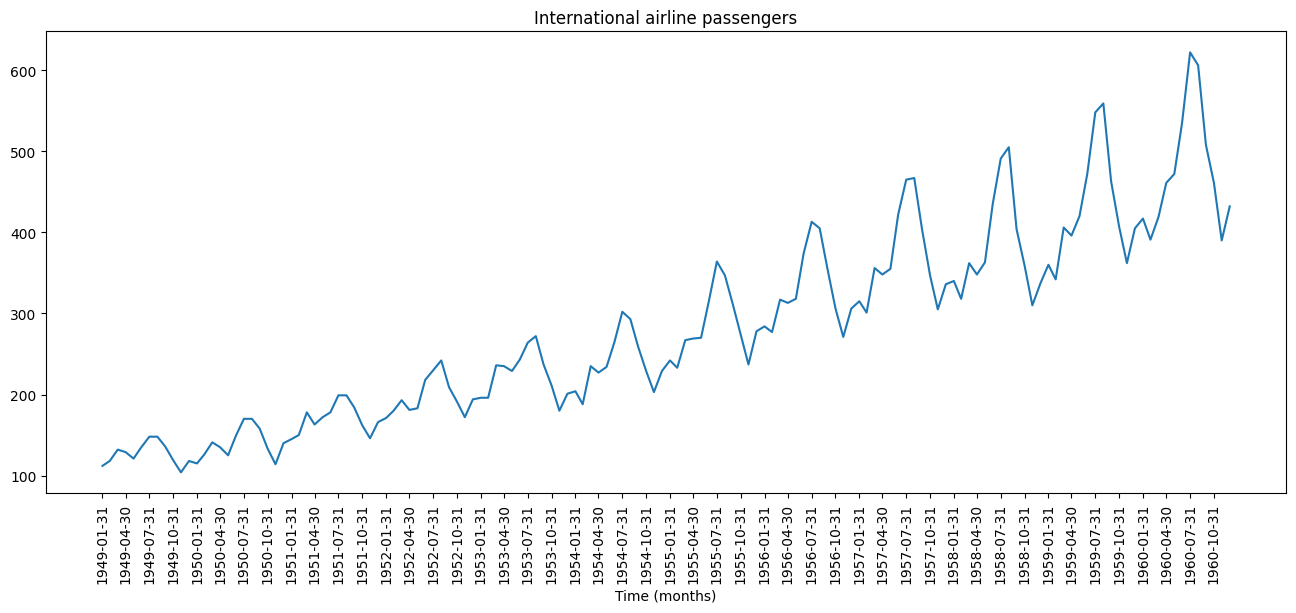

In [5]:
# creamos una variable para
# el tiempo
Time = pd.date_range(np.datetime64('1949-01'), np.datetime64('1961-01'), freq='M')
print("tenemos dispnible nuestra base de datos en el pandas DF 'dataset' \n")
fig, ax = plt.subplots(figsize = (16,6))
ax.plot(Time,dataset)
ax.set_title('International airline passengers')
ax.set_xlabel('Time (months)')
ax.set_xticks( pd.date_range(np.datetime64('1949-01'), np.datetime64('1961-01'), freq='3M'))
plt.xticks(rotation=90)
plt.show()

En nuestro primer ejercicio vamos a explorar, el patrón que observamos en la grafica anterior. Esto tambien nos puede decir qué relación existe entre una muestra en el tiempo $t$ con las muestras anteriores.

La libreria statsmodel [tiene una función que nos sirve para analizar esta relación](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html).


## Ejercicio 1 - Exploración del problema

Este plot realiza una operación cuyos detalles son explicados en mayor profundidad en [esta buena entrada de blog](https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/). Pero en este laboratorio lo que no interesa entender es:

1. El valor varia entre 1.0 y -1.0.
2. Cuando el valor de la correlación es 1.0, corresponde el valor maximo indicando una relación positiva entre la variable y su correspondiente lag o retraso.
3. Cuando el valor de la correlación es -1.0, corresponde el valor mínimo indicando una relación negativa entre la variable y su correspondiente lag o retraso..
4. 0.0 indica que los valores no están relacionados.
5. el lag indica, el número de retrasos. Si el valor de la correlación en el lag  5 es igual 0.75, indica una relación positiva alta entre el actaul y el quinto retraso anterior en la mayoria de muestras de nuestra variable de respuesta.

Ahora, grafiquemos la correlación para un maximo de 36 lags de nuestros datos. Esto significa que estamos analizando las relación de una muestras respecto a la 36 muestras pasdas.

Sabiendo que nuestro eje X representa los meses y nuestro eje y representan el numero de pasajeros. Al realizar el analisis de lags estamos determinando si el número de pasajeros de los meses pasados tiene influencia en el nuúmero de pasajeros en el mes acutal.

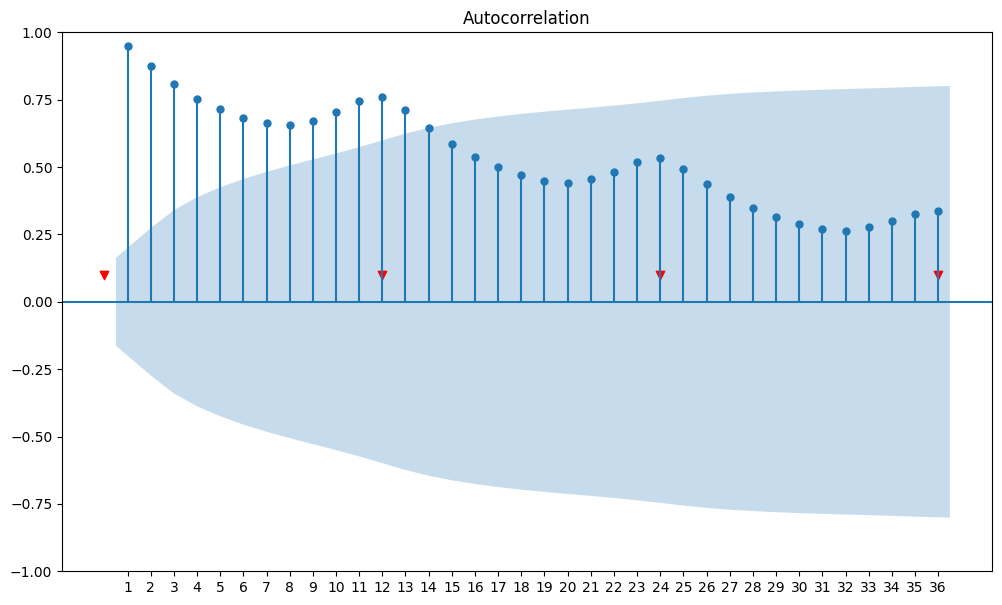

In [6]:
from statsmodels.graphics import tsaplots
fig, ax = plt.subplots(figsize = (12,7))
# Display the autocorrelation plot of your time series
fig = tsaplots.plot_acf(dataset.passengers, lags=range(1,37), ax = ax)
ax.set_xticks( range(1,37))
ax.scatter(range(0,37,12), 0.1*np.ones(4), c = 'r', marker = "v")
plt.show()

reforzando el entendimiento, observando la grafica anterior:

1. Cuando hay un lag = 5 (es decir se evalúa qué tan relacionadas están las 5 muestras anteriores), tenemos una autocorrelación $\approx$ 0.75
2. Cuando hay un lag = 25 (es decir se evalúa qué tan relacionadas están las 25 muestras anteriores), tenemos una autocorrelación $\approx$ 0.5
3. Presta atención al patrón que se resalta con las marcas rojas

Vamos a observar estas relaciones viendo cómo los picos de correlación se relacionan con los patrones que vemos. A continuación, graficamos los valores de autocorrelación junto con la serie de los valores reales.

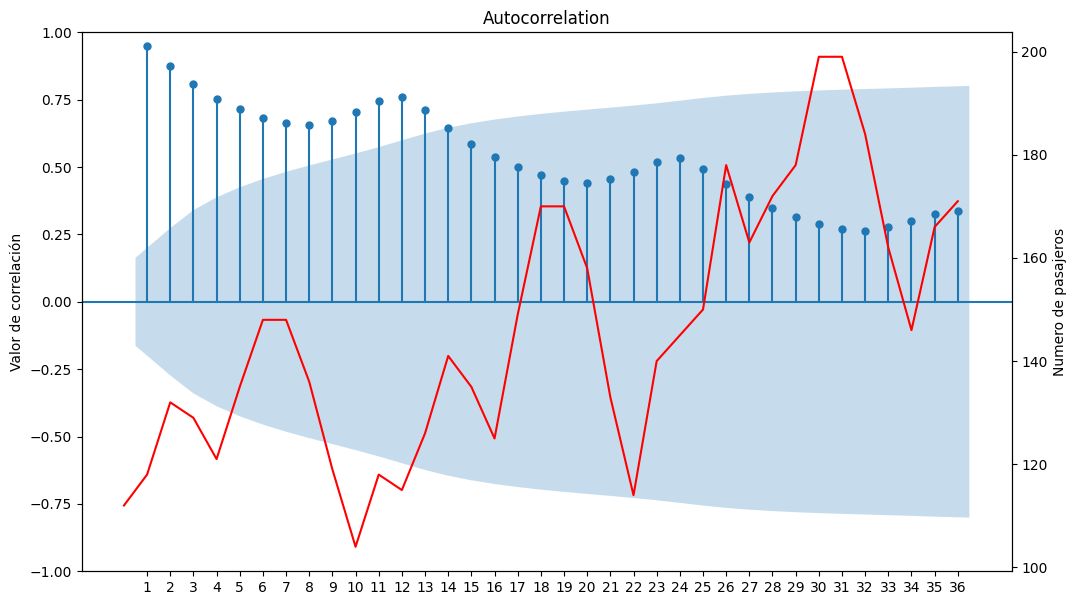

In [7]:
fig, ax = plt.subplots(figsize = (12,7))
# Display the autocorrelation plot of your time series
fig = tsaplots.plot_acf(dataset.passengers, lags=range(1,37), ax = ax)
ax.set_xticks( range(1,37))
ax.set_ylabel("Valor de correlación")
ax2 = ax.twinx()
ax2.set_ylabel("Numero de pasajeros")
ax2.plot(dataset[0:37], c = 'r')
plt.show()

Ahora bien, para poder aplicar una RNN, debemos transformar los datos. Observa la figura, para entender como debemos transformar los datos.

![rnn](https://raw.githubusercontent.com/jdariasl/ML_2020/master/Labs/commons/images/UDEA%20-%20RNN.jpg)

Con base en el análisis de correlación que reveló cómo están  relacionadas la muestra actual y las anteriores y teniendo en cuenta que la preparación de los datos consiste en usar las muestras pasadas para predicir la muestra siguiente. Responde la siguiente pregunta.

In [ ]:
#@title Pregunta Abierta
#@markdown ¿Cual podría ser el número máximo de muestras pasadas para transformar el conjunto de datos?
respuesta = "" #@param {type:"string"}

Ahora, realicemos el ejercicio de transformar nuestros datos a la forma requerida.

In [82]:
#ejercicio de codigo
def create_dataset(dataset, look_back=1):
    """función que crea dataset apto para RNN

    dataset: matriz numpy con el conjunto de datos
    look_back: número de retrasos con los cuales queremos construir
        las características

    Retorna:
      X: un numpy array con los valores de entrada a la red (debe ser una matrix)
      Y: un numpy array con los valores de salida deseada de la red
    """
    dataset = np.array(dataset)
    if dataset.ndim == 1:
        dataset = dataset.reshape(-1, 1)

    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])


    return np.array(X), np.array(Y).reshape(-1,1)

**Registra tu solución en línea**

In [83]:
student.submit_task(namespace=globals(), task_id='T1');

In [12]:
# observemos el funcionamiento de nuestra funcion
x_to_see, y_to_see =  create_dataset(dataset.values, 3)
display("primeras muestras de x", x_to_see[0:3])
display("primeras muestras de y", y_to_see[0:3])

'primeras muestras de x'

array([[112, 118, 132],
       [118, 132, 129],
       [132, 129, 121]])

'primeras muestras de y'

array([129, 121, 135])

## Ejercicio 2 - Crear una RNN

Al igual que en laboratorio anterior, vamos a usar [PyTorch](https://pytorch.org/) para diseñar y construir las redes neuronales con las que vamos a experimentar.

En el siguiente ejercicio vamos a crear una función para construir una RNN usando la libreria mencionada.  Deben revisar con detenimiento la documentación de las capas tipo [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html).

In [77]:
def create_rnn_model(num_hidden_neurons):
    import torch.nn as nn

    class Recurrent_NN(nn.Module):
      def __init__(self, num_hidden_neurons):
          super().__init__()
          self.rnn = nn.RNN(input_size=1, hidden_size=num_hidden_neurons, batch_first=True)
          self.linear = nn.Linear(num_hidden_neurons, 1)

      def forward(self, x):
          _, h = self.rnn(x)
          x = h.squeeze()
          x = self.linear(x)
          return x

    return Recurrent_NN(num_hidden_neurons)


**Registra tu solución en línea**

In [14]:
student.submit_task(namespace=globals(), task_id='T2');

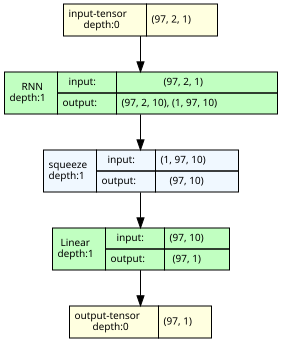

In [15]:
#Grafiquemos las arquitecturas de dos modelos con parámetros diferentes:

import torch
from torchview import draw_graph
input_data = np.random.randn(100)
look_back = 2
X, _ = create_dataset(input_data,look_back=look_back)
X = torch.from_numpy(X).float()
# Una capa RNN recibe entradas de dimensión (Batch,Tiempo,Dimensión). En realidad queremos que los
# retardos sean entendidos como muestras pasadas (Tiempos), por lo tanto agregamos
# una dimensión al final para que el modelo lea los datos como valores pasados de 1
# dimensión.
X = X.unsqueeze(2)
model =  create_rnn_model(num_hidden_neurons = 10)
model_graph = draw_graph(model, input_size=X.shape)
model_graph.visual_graph

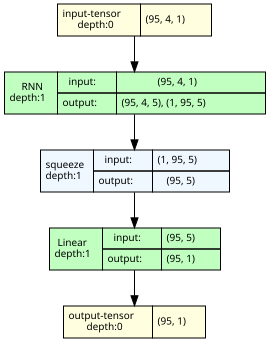

In [16]:
look_back = 4
X, _ = create_dataset(input_data,look_back=look_back)
X = torch.from_numpy(X).float()
X = X.unsqueeze(2)
model =  create_rnn_model(num_hidden_neurons = 5)
model_graph = draw_graph(model, input_size=X.shape)
model_graph.visual_graph

## Ejercicio 3: Experimentar con RNN

Con nuestra función que crea modelos, vamos experimentar variando los dos parametros:

- número de retrasos
- número de neuronas en la capa oculta

Otras condiciones:
- Vamos a dejar fijo el # de epocas 50.
- Usaremos la métrica MAE (ver [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html))


In [84]:
def experimentar_rnn(data, look_backs, hidden_neurons):
    scaler = MinMaxScaler(feature_range=(0, 1))
    dataset = scaler.fit_transform(data)
    train_size = int(len(dataset) * 0.7)
    test_size = len(dataset) - train_size
    train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
    resultados = pd.DataFrame()
    idx = 0
    for num_hidden_neurons in hidden_neurons:
        for look_back in look_backs:
            trainX, trainY = create_dataset(train, look_back)
            trainX = torch.from_numpy(trainX).float().unsqueeze(2)
            trainY = torch.from_numpy(trainY).float()

            testX, testY = create_dataset(test, look_back)
            testX = torch.from_numpy(testX).float().unsqueeze(2)

            model = create_rnn_model(num_hidden_neurons)
            loss = torch.nn.L1Loss()
            optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

            for epoch in range(50):
                model.train()
                optimizer.zero_grad()
                trainYPred = model(trainX)
                trainLoss = loss(trainYPred, trainY)
                trainLoss.backward()
                optimizer.step()

            model.eval()
            trainYPred = model(trainX)
            testYPred = model(testX)

            errorEntrenamiento = mean_absolute_error(trainY.detach().numpy(), trainYPred.detach().numpy())
            errorPrueba = mean_absolute_error(testY, testYPred.detach().numpy())

            resultados.loc[idx,'lags'] = look_back
            resultados.loc[idx,'neuronas por capa'] = num_hidden_neurons
            resultados.loc[idx,'error de entrenamiento'] = errorEntrenamiento
            resultados.loc[idx,'error de prueba'] = errorPrueba
            idx+=1
            print("termina para", look_back, num_hidden_neurons)

    return resultados

In [85]:
student.submit_task(namespace=globals(), task_id='T3');

Ahora vamos a ver los resultados del experimento:

1. variando los lags dejando las neuronas por capa fijas
2. variando las neuronas y dejando los retrasos fijos

Si la semilla no se ajusta los resultados pueden cambiar debido a la inicialización aleatoria de la red y al tamaño limitado de la serie de tiempo.

Text(0.5, 0.98, 'efecto del # retrasos')

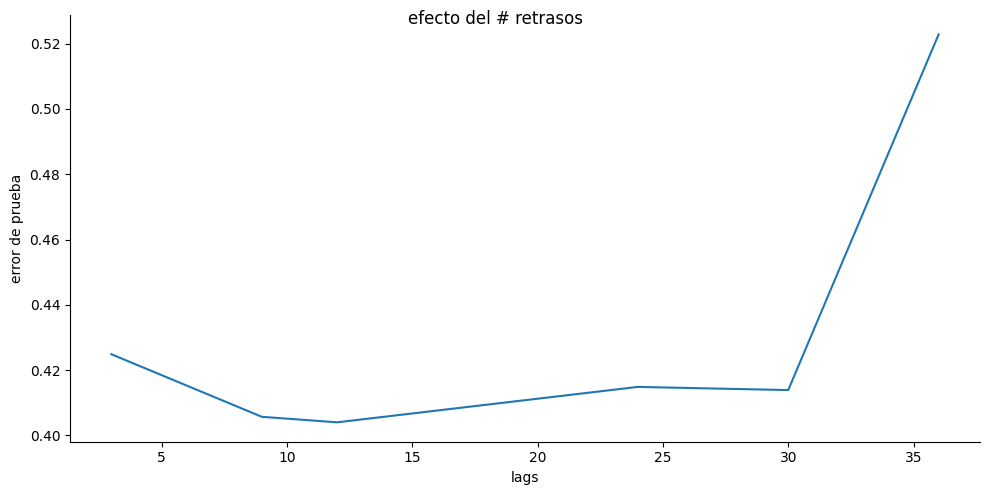

In [64]:
# observa el comportamiento de los lags
import seaborn as sns
import torch.nn as nn
import torch
torch.manual_seed(2)
np.random.seed(2)
resultadosRNN = experimentar_rnn(dataset, look_backs = [3,9,12,24,30,36], hidden_neurons=[15])
# plot
ax1  = sns.relplot(data= resultadosRNN, x= 'lags', y = 'error de prueba', kind = 'line', aspect = 2)
ax1.fig.suptitle('efecto del # retrasos')

Text(0.5, 0.98, 'efecto del # neuronas')

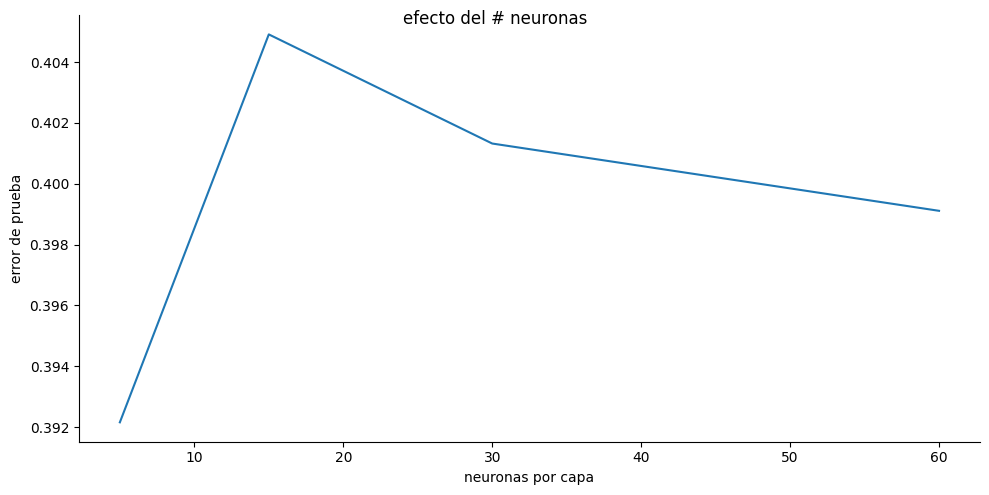

In [65]:
torch.manual_seed(2)
np.random.seed(2)
resultadosRNN = experimentar_rnn(dataset, look_backs = [9], hidden_neurons=[5,15,30,60])
ax2  = sns.relplot(data= resultadosRNN, x= 'neuronas por capa', y = 'error de prueba', kind = 'line', aspect = 2)
ax2.fig.suptitle('efecto del # neuronas')

In [ ]:
#@title Pregunta Abierta
#@markdown ¿Por qué seguir aumentando los tiempos de retardo no implica siempre una mejora en la predicción del modelo?
respuesta = "" #@param {type:"string"}

## Ejercicio 4 - Comparación con MLP

En este ejercicio vamos a resolver el mismo problema, pero con un MLP. Con esto vamos a comparar los resultados obtenidos con la RNN.

Seguiremos las siguientes reglas:
1. Variar el número de retrasos, que corresponden en este caso al número de características en la capa de entrada
2. Usaremos solo una capa oculta y evaluaremos diferente número de neuronas en esta capa
3. El número de epocas también se ajustará a 50
4. Usaremos las misma métrica y función de coste empleadas en el ejercicio anterior.

In [66]:
def create_mlp_model(look_back, num_hidden_neurons):
    import torch.nn as nn
    model = nn.Sequential(
        nn.Linear(look_back, num_hidden_neurons),
        nn.ReLU(),
        nn.Linear(num_hidden_neurons, 1)
    )
    return model


def experimentar_MLP(data, look_backs, hidden_neurons):
    scaler = MinMaxScaler(feature_range=(0, 1))
    dataset = scaler.fit_transform(data)
    train_size = int(len(dataset) * 0.7)
    test_size = len(dataset) - train_size
    train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
    resultados = pd.DataFrame()
    idx = 0
    for num_hidden_neurons in hidden_neurons:
        for look_back in look_backs:

            trainX, trainY = create_dataset(train, look_back)
            trainX = torch.from_numpy(trainX).float()
            trainY = torch.from_numpy(trainY).float().reshape(-1,1)

            testX, testY = create_dataset(test, look_back)
            testX = torch.from_numpy(testX).float()

            model = create_mlp_model(look_back, num_hidden_neurons)
            loss = torch.nn.L1Loss()
            optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

            for epoch in range(50):
                model.train()
                optimizer.zero_grad()
                trainYPred = model(trainX)
                trainLoss = loss(trainYPred, trainY)
                trainLoss.backward()
                optimizer.step()

            model.eval()
            trainYPred = model(trainX)
            testYPred = model(testX)

            errorEntrenamiento = mean_absolute_error(trainY.detach().numpy(), trainYPred.detach().numpy())
            errorPrueba = mean_absolute_error(testY, testYPred.detach().numpy())

            resultados.loc[idx,'lags'] = look_back
            resultados.loc[idx,'neuronas por capa'] = num_hidden_neurons
            resultados.loc[idx,'error de entrenamiento'] = errorEntrenamiento
            resultados.loc[idx,'error de prueba'] = errorPrueba
            idx += 1
            print("termina para", look_back, num_hidden_neurons)

    return resultados

**Registra tu solución en línea**

In [67]:
student.submit_task(namespace=globals(), task_id='T4');

In [ ]:
resultadosMLP = experimentar_MLP(dataset, look_backs = [3,9,12,24,30,36], hidden_neurons=[10,20,30])

In [ ]:
# para ver los resultados
# en esta instrucción se va resaltar el menor error
resultadosMLP.style.highlight_min(color = 'green', axis = 0, subset = ['error de prueba'])

## Ejercicio 5 - Construcción de modelo LSTM

En nuestro ultimo ejercicio, vamos a crear una arquitectura de red con una capa LSTM en lugar de una capa RNN. (Ver la documentación de PyTorch sobre este tipo de capas [link](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)).



In [ ]:
#@title Pregunta Abierta
#@markdown ¿Por qué una red LSTM puede ser más adecuada para resolver este problema?
respuesta = "" #@param {type:"string"}

In [68]:
def create_lstm_model(num_hidden_neurons):
    import torch.nn as nn

    class LSTM_net(nn.Module):
      def __init__(self, num_hidden_neurons):
          super().__init__()
          self.lstm = nn.LSTM(input_size=1, hidden_size=num_hidden_neurons, batch_first=True)
          self.linear = nn.Linear(num_hidden_neurons, 1)

      def forward(self, x):
          _, (h, c) = self.lstm(x)
          x = h.squeeze()
          x = self.linear(x)
          return x

    return LSTM_net(num_hidden_neurons)

**Registra tu solución en línea**

In [69]:
student.submit_task(namespace=globals(), task_id='T5');

In [ ]:
look_back = 4
X, _ = create_dataset(input_data,look_back=look_back)
X = torch.from_numpy(X).float()
X = X.unsqueeze(2)
model =  create_lstm_model(num_hidden_neurons = 5)
model_graph = draw_graph(model, input_size=X.shape)
model_graph.visual_graph

Una vez superada la prueba, pueden usar el modelo creado para realizar experimentación de manera similar al ejercicio 3. La función de experimentación es igual, simplemente es necesario reemplezar la función `create_rnn_model` por la nueva `create_lstm_model` y ejecutar los experimentos.